<a href="https://colab.research.google.com/github/amer-baniodeh/project-1-deep-learning-image-classification-with-cnn/blob/main/model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical



from google.colab import drive
drive.mount('/content/drive')


# Load the training data
x_train = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/x_train.npy')
y_train = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/y_train.npy')

# Load the test data
x_test = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/x_test.npy')
y_test = np.load('/content/drive/MyDrive/IronHack/datasets/cifar10_data/y_test.npy')

# Verify the shapes to make sure everything loaded correctly
print(f"x_train shape: {x_train.shape} | y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} | y_test shape: {y_test.shape}")



Mounted at /content/drive
x_train shape: (50000, 32, 32, 3) | y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3) | y_test shape: (10000, 1)


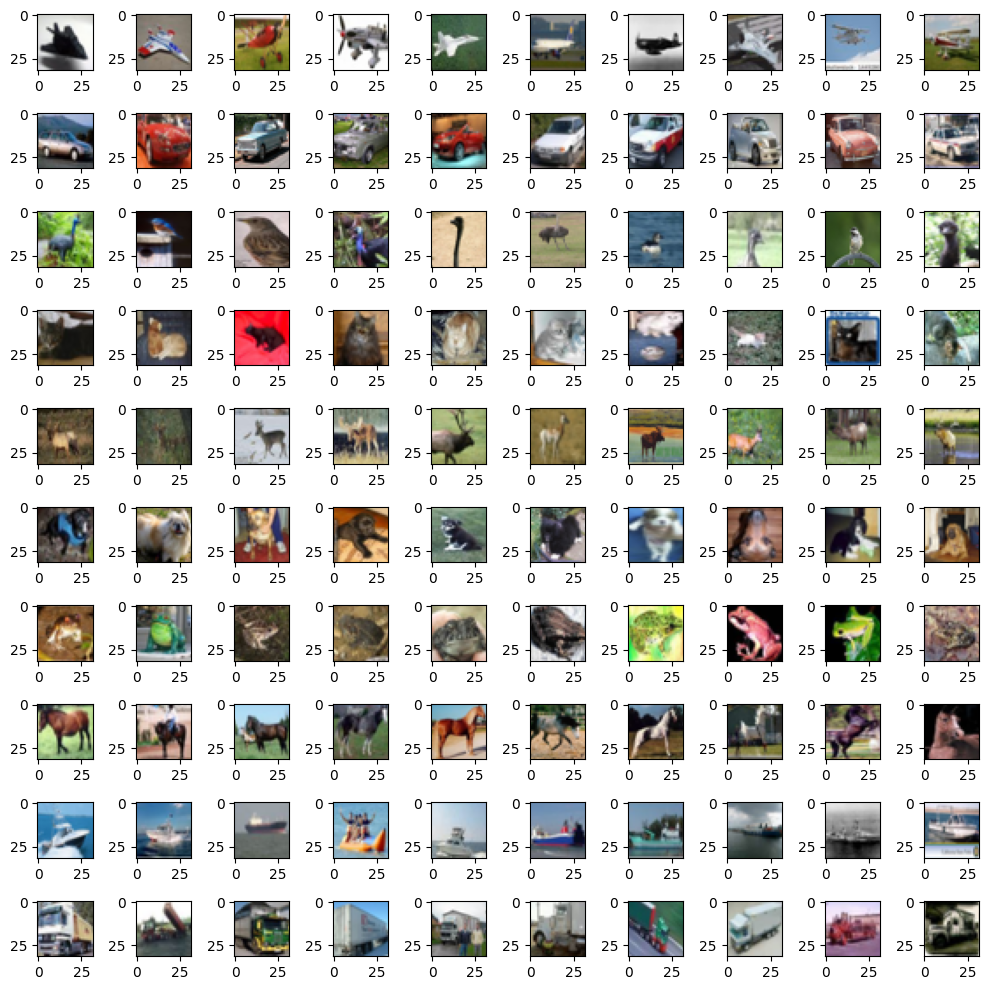

In [3]:
plt.figure(figsize=(10, 10))

for class_id in range(10):
    class_indices = np.where(y_train == class_id)[0]

    # Grab 10 samples for this class
    for sample_idx in range(10):
        # Calculate the 1-indexed grid position (1 to 100)
        position = (class_id * 10) + sample_idx + 1
        img_index = class_indices[sample_idx]

        plt.subplot(10, 10, position)
        plt.imshow(x_train[img_index])
        plt.axis('on')

plt.tight_layout()
plt.show()

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Use .item() instead of int()
sample_index = y_train[7].item()

print(f"Integer label: {sample_index}")
print(f"Human-readable label: {class_names[sample_index]}")

Integer label: 7
Human-readable label: horse


In [5]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# SPLIT FIRST (e.g., 80% train, 20% validation)
# 'stratify=y_train_full' ensures an equal mix of CIFAR-10 classes in both sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# ONE-HOT ENCODE EVERYTHING
num_classes = 10
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)

# Check new shapes
print("Train shape:", y_train_one_hot.shape)  # Output: (40000, 10)
print("Val shape:", y_val_one_hot.shape)      # Output: (10000, 10)
print("Test shape:", y_test_one_hot.shape)    # Output: (10000, 10)

Train shape: (40000, 10)
Val shape: (10000, 10)
Test shape: (10000, 10)


In [6]:
#Normalise
def normalize_images(df):
    df = df.astype('float32') / 255
    return df

x_train = normalize_images(x_train)
x_val = normalize_images(x_val)
x_test = normalize_images(x_test)

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)


(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [7]:
#Define the improved model with VGG (model_2)

from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# VGG-style CNN
model_vgg = Sequential([
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),

    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_vgg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from IPython.core import history
from tensorflow.keras.optimizers import SGD

# Compile the model
model_vgg.compile(loss='categorical_crossentropy',
              optimizer=SGD(learning_rate=0.01),
              metrics=['accuracy'])

history = model_vgg.fit(x_train, y_train_one_hot, batch_size=512, epochs=50, validation_split=0.1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.1583 - loss: 2.2635 - val_accuracy: 0.2393 - val_loss: 2.2205
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2417 - loss: 2.1503 - val_accuracy: 0.1758 - val_loss: 2.1535
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2717 - loss: 2.0437 - val_accuracy: 0.2600 - val_loss: 2.0642
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2943 - loss: 1.9811 - val_accuracy: 0.2403 - val_loss: 2.1477
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3174 - loss: 1.9277 - val_accuracy: 0.3153 - val_loss: 1.9348
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3294 - loss: 1.8977 - val_accuracy: 0.2925 - val_loss: 1.9755
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3477 - loss: 1.8478 - val_accuracy: 0.3257 - val_loss: 1.8595
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3598 - loss: 1.8208 - val_accuracy: 0.3645 - val_lo

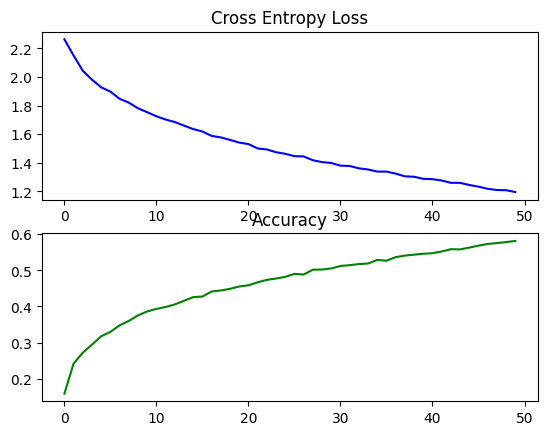

In [10]:
#Plot the cross entropy loss curve and the accuracy curve
plt.subplot(211)
plt.title('Cross Entropy Loss')
plt.plot(history.history['loss'], color='blue', label='train')

plt.subplot(212)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], color='green', label='train')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


<Figure size 1000x800 with 0 Axes>

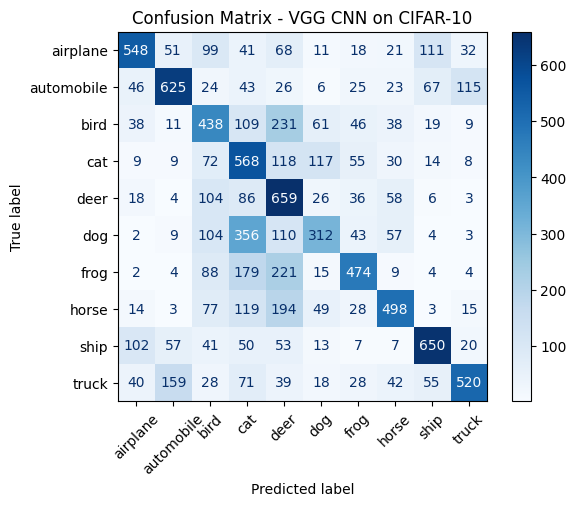

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict class probabilities
y_pred_prob = model_vgg.predict(x_val)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded test labels back to class labels
y_true = np.argmax(y_val_one_hot, axis=1)


#######################

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - VGG CNN on CIFAR-10")
plt.show()

In [14]:
model_vgg.save("/content/drive/MyDrive/IronHack/Models/model_2.keras")


In [15]:

from tensorflow.keras.models import load_model

m = load_model("/content/drive/MyDrive/IronHack/Models/model_2.keras")
print("Loaded successfully")

'''
import pickle

model_path = "/content/drive/MyDrive/Models/model_3.keras"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("Model saved to:", model_path)
'''

Loaded successfully


'\nimport pickle\n\nmodel_path = "/content/drive/MyDrive/Models/model_3.keras"\n\nwith open(model_path, "wb") as f:\n    pickle.dump(model, f)\n\nprint("Model saved to:", model_path)\n'

In [ ]:
'''
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully!")
'''

Model loaded successfully!
